# Membandingkan Model Forecasting PM2.5 Jakarta

Notebook ini digunakan untuk membandingkan beberapa pendekatan model forecasting PM2.5 Jakarta pada tiga horizon prediksi, yaitu **6 jam**, **12 jam**, dan **24 jam** ke depan.

Input utama notebook ini adalah tiga dataset modeling yang sudah dibuat pada tahap preprocessing sebelumnya:

```text
dataset_h6.csv
dataset_h12.csv
dataset_h24.csv
```

Masing-masing dataset memiliki target prediksi yang berbeda:

| Dataset | Horizon Prediksi | Target |
|---|---:|---|
| `dataset_h6.csv` | 6 jam ke depan | `target_pm25_t_plus_6` |
| `dataset_h12.csv` | 12 jam ke depan | `target_pm25_t_plus_12` |
| `dataset_h24.csv` | 24 jam ke depan | `target_pm25_t_plus_24` |

Notebook ini membandingkan model baseline sederhana, model time-series klasik, dan model machine learning berbasis tree. Tujuannya adalah melihat apakah model yang lebih kompleks seperti **LightGBM**, **XGBoost**, dan **CatBoost** benar-benar memberikan performa lebih baik dibanding pendekatan sederhana seperti **moving average** dan **ARIMA**.

Dengan demikian, notebook ini berperan sebagai tahap **model comparison** untuk menentukan model mana yang paling layak dilanjutkan sebagai kandidat model final forecasting PM2.5.

## Evaluasi Berbasis Walk-Forward Validation

Notebook ini menggunakan pendekatan **walk-forward time-series validation**. Pendekatan ini lebih sesuai untuk forecasting karena data training selalu berasal dari periode masa lalu, sedangkan data validation berasal dari periode setelahnya.

Alur validasi dapat diringkas sebagai berikut:

```text
Dataset horizon
        ↓
Urutkan berdasarkan datetime dan station_slug
        ↓
Buat 4 fold walk-forward validation
        ↓
Untuk setiap fold:
    - training memakai data historis sebelum validation
    - validation memakai periode waktu setelah training
    - diberi purge gap sesuai horizon
        ↓
Latih atau hitung prediksi setiap model
        ↓
Hitung MAE dan RMSE
        ↓
Gabungkan hasil semua fold
```

Validasi ini menggunakan **4 fold** untuk setiap horizon. Setiap fold mengevaluasi performa model pada periode waktu yang berbeda, sehingga hasil evaluasi tidak hanya bergantung pada satu periode validation saja.

Notebook juga menerapkan **purge gap** sesuai horizon. Artinya, ada jarak antara akhir data training dan awal data validation.

| Horizon | Purge Gap |
|---:|---:|
| H6 | 6 jam |
| H12 | 12 jam |
| H24 | 24 jam |

Purge gap penting karena target prediksi dibuat dengan menggeser PM2.5 ke masa depan. Tanpa purge gap, evaluasi bisa menjadi terlalu optimistis karena data training terlalu dekat dengan target validation.

## Model yang Dibandingkan

Notebook ini membandingkan lima pendekatan utama:

| Model | Jenis Pendekatan | Keterangan |
|---|---|---|
| `moving_avg` | Baseline statistik sederhana | Menggunakan rolling mean PM2.5 historis |
| `arima_111` | Time-series klasik | ARIMA(1,1,1) per stasiun |
| `lightgbm_best` | Machine learning boosting | LightGBM dengan best params dari notebook tuning |
| `xgboost` | Machine learning boosting | XGBoost dengan konfigurasi tetap |
| `catboost` | Machine learning boosting | CatBoost dengan konfigurasi tetap |

Model `moving_avg` digunakan sebagai baseline sederhana. Jika model machine learning tidak mampu mengalahkan moving average, berarti model tersebut belum cukup kuat untuk forecasting PM2.5.

Model `arima_111` digunakan sebagai baseline time-series klasik. ARIMA dilatih per stasiun karena setiap stasiun memiliki pola PM2.5 yang berbeda.

Model `lightgbm_best` menggunakan hyperparameter terbaik dari notebook optimasi sebelumnya. Model ini menjadi kandidat utama karena sudah melewati proses tuning.

Model `xgboost` dan `catboost` digunakan sebagai pembanding tambahan untuk melihat apakah algoritma boosting lain mampu mengungguli LightGBM pada dataset ini.

## Output Model Comparison dan Kegunaannya

Notebook ini menghasilkan beberapa output penting untuk analisis model comparison.

Output utama notebook meliputi:

| Output | Fungsi |
|---|---|
| `model_comparison.csv` | Ringkasan performa rata-rata setiap model pada setiap horizon |
| `model_comparison_by_fold.csv` | Detail MAE dan RMSE per fold |
| `model_comparison_h6.png` | Grafik perbandingan model untuk horizon 6 jam |
| `model_comparison_h12.png` | Grafik perbandingan model untuk horizon 12 jam |
| `model_comparison_h24.png` | Grafik perbandingan model untuk horizon 24 jam |
| `predictions_h6_all_models.csv` | Gabungan prediksi semua model untuk H6 |
| `predictions_h12_all_models.csv` | Gabungan prediksi semua model untuk H12 |
| `predictions_h24_all_models.csv` | Gabungan prediksi semua model untuk H24 |
| File `.pkl` model | Model XGBoost dan CatBoost per fold |

Output tersebut dapat digunakan untuk:

1. Menentukan model terbaik berdasarkan rata-rata CV MAE.
2. Mengecek stabilitas model dari fold ke fold.
3. Membandingkan performa model antarhorizon.
4. Membuat visualisasi actual vs prediction.
5. Menyimpan hasil prediksi agar bisa dianalisis kembali tanpa menjalankan training ulang.

Secara keseluruhan, notebook ini menjadi dasar untuk memilih model terbaik sebelum masuk ke tahap interpretasi hasil, visualisasi forecast, dan penentuan model final.

## Menyiapkan Library, Dataset, dan Folder Output

Cell ini menyiapkan library utama, konfigurasi eksperimen, path dataset, dan folder output untuk model comparison.

Library yang digunakan adalah:

| Library | Fungsi |
|---|---|
| `json` | Membaca best params LightGBM dari file JSON |
| `pathlib.Path` | Mengatur path folder output |
| `pickle` | Menyimpan model dalam format `.pkl` |
| `warnings` | Menyembunyikan warning agar output notebook lebih bersih |
| `numpy` | Operasi numerik |
| `pandas` | Membaca dan mengolah dataset |
| `sklearn.metrics` | Menghitung MAE dan RMSE |
| `LightGBM` | Model boosting hasil tuning |
| `XGBoost` | Model boosting pembanding |
| `CatBoost` | Model boosting pembanding |
| `ARIMA` | Model time-series klasik |

Konfigurasi utama notebook adalah:

| Konfigurasi | Nilai |
|---|---|
| `SEED` | 42 |
| `N_FOLDS` | 4 |
| `PHASE2_DIR` | `outputs_phase2/` |
| `OUT_DIR` | `outputs_model_comparison/` |
| `MODEL_DIR` | `outputs_model_comparison/saved_models/` |
| `PRED_DIR` | `outputs_model_comparison/saved_predictions/` |

Dataset input didefinisikan dalam dictionary `DATASET_PATHS`.

| Horizon | File Dataset |
|---:|---|
| 6 | `dataset_h6.csv` |
| 12 | `dataset_h12.csv` |
| 24 | `dataset_h24.csv` |

Folder `outputs_phase2/` digunakan untuk mengambil best params LightGBM dari notebook optimasi sebelumnya. Sementara itu, folder `outputs_model_comparison/` digunakan untuk menyimpan hasil model comparison pada notebook ini.

In [1]:
import json
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

SEED = 42
N_FOLDS = 4

DATASET_PATHS = {
    6: "dataset_h6.csv",
    12: "dataset_h12.csv",
    24: "dataset_h24.csv",
}

PHASE2_DIR = Path("outputs_phase2")
OUT_DIR = Path("outputs_model_comparison")
OUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = OUT_DIR / "saved_models"
PRED_DIR = OUT_DIR / "saved_predictions"

MODEL_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)

## Menyiapkan Fungsi Data, Fold, dan Fitur Model

Cell ini mendefinisikan beberapa fungsi dasar yang digunakan oleh seluruh proses model comparison.

### Fungsi `load_dataset()`

Fungsi ini membaca dataset horizon, mengubah kolom `datetime` dan `date` menjadi format datetime, lalu mengurutkan data berdasarkan:

```text
datetime
station_slug
```

Pengurutan ini penting karena data bersifat time series. Semua proses validasi harus mengikuti urutan waktu agar tidak terjadi kebocoran informasi dari masa depan.

### Fungsi `make_walk_forward_folds()`

Fungsi ini membuat fold validasi berbasis waktu menggunakan pendekatan **expanding-window cross-validation**.

Setiap fold memiliki:

| Komponen | Makna |
|---|---|
| `fold_id` | Nomor fold |
| `train_idx` | Index baris training |
| `valid_idx` | Index baris validation |
| `train_end` | Batas akhir periode training |
| `valid_start` | Awal periode validation |
| `valid_end` | Akhir periode validation |

Fungsi ini juga menerapkan purge gap sesuai horizon. Misalnya, untuk horizon 24 jam, data training akan berhenti 24 jam sebelum validation dimulai.

### Fungsi `prepare_xy_onehot()`

Fungsi ini memisahkan fitur `X` dan target `y`, lalu melakukan one-hot encoding untuk kolom object atau category.

Beberapa kolom dikeluarkan dari fitur:

| Kolom | Alasan Dikeluarkan |
|---|---|
| Target horizon | Label yang harus diprediksi |
| `datetime` | Kolom waktu mentah |
| `date` | Kolom tanggal mentah |
| `station_name` | Redundan dengan `station_slug` |
| `lokasi` | Kolom teks lokasi |
| `season_simple` | Kolom string musim |
| `pm25_raw` | Backup PM2.5 asli sebelum imputasi |
| `pm25_clean_full` | Duplikasi PM2.5 final jika tersedia |

One-hot encoding dilakukan agar model seperti XGBoost dan CatBoost dapat menerima fitur kategorikal dalam bentuk numerik yang konsisten.

### Fungsi `choose_moving_average_col()`

Fungsi ini memilih kolom rolling mean PM2.5 yang paling sesuai dengan horizon. Jika tersedia, fungsi akan memilih kolom:

```text
pm25_roll_mean_{horizon}
```

Jika kolom tersebut tidak tersedia, fungsi akan mencari rolling mean dengan window yang paling dekat dengan horizon.

### Fungsi `load_best_lgb_params()`

Fungsi ini membaca best params LightGBM dari folder:

```text
outputs_phase2/
```

Jika file best params tersedia, parameter tersebut digunakan untuk model `lightgbm_best`. Jika tidak tersedia, LightGBM akan menggunakan parameter default.

In [2]:
def load_dataset(path):
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
    return df


def make_walk_forward_folds(df, horizon, n_folds=4, valid_ratio_each=0.10):
    """
    Expanding-window CV + purge gap sesuai horizon.
    """
    df = df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
    unique_times = pd.Series(sorted(df["datetime"].dropna().unique()))

    n_times = len(unique_times)
    valid_size = max(1, int(n_times * valid_ratio_each))
    total_valid = n_folds * valid_size

    if total_valid >= n_times:
        raise ValueError("Terlalu banyak fold atau valid_ratio terlalu besar.")

    first_valid_start_idx = n_times - total_valid
    folds = []

    for fold_id in range(n_folds):
        valid_start_idx = first_valid_start_idx + fold_id * valid_size
        valid_end_idx = min(valid_start_idx + valid_size - 1, n_times - 1)

        valid_start = pd.Timestamp(unique_times.iloc[valid_start_idx])
        valid_end = pd.Timestamp(unique_times.iloc[valid_end_idx])

        # purge gap
        train_end = valid_start - pd.Timedelta(hours=horizon)

        train_mask = df["datetime"] < train_end
        valid_mask = (df["datetime"] >= valid_start) & (df["datetime"] <= valid_end)

        folds.append({
            "fold_id": fold_id + 1,
            "train_idx": df.index[train_mask].to_numpy(),
            "valid_idx": df.index[valid_mask].to_numpy(),
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
        })

    return folds


def prepare_xy_onehot(df, target_col):
    """
    Satu matriks fitur untuk semua model tree,
    object/category di-one-hot agar konsisten.
    """
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "station_name",
        "lokasi",
        "season_simple",
        "pm25_raw",
        "pm25_clean_full",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)

    return X, y


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def choose_moving_average_col(df, horizon):
    preferred = f"pm25_roll_mean_{horizon}"
    if preferred in df.columns:
        return preferred

    candidates = [c for c in df.columns if c.startswith("pm25_roll_mean_")]
    if not candidates:
        return None

    # pilih window terdekat
    candidate_windows = []
    for c in candidates:
        try:
            w = int(c.split("_")[-1])
            candidate_windows.append((c, w))
        except:
            pass

    candidate_windows = sorted(candidate_windows, key=lambda x: abs(x[1] - horizon))
    return candidate_windows[0][0] if candidate_windows else None


def load_best_lgb_params(horizon):
    fp = PHASE2_DIR / f"best_params_h{horizon}.json"
    if fp.exists():
        with open(fp, "r") as f:
            obj = json.load(f)
        return obj.get("best_params", {})
    return {}

## Menyusun Evaluasi Baseline Moving Average dan ARIMA

Cell ini mendefinisikan fungsi evaluasi untuk baseline non-tree, yaitu **moving average** dan **ARIMA(1,1,1)**.

### Fungsi `eval_persistence()`

Fungsi ini mengevaluasi baseline persistence, yaitu memprediksi target masa depan menggunakan nilai PM2.5 saat ini.

Secara konsep, baseline persistence berarti:

```text
prediksi PM2.5 t+h = PM2.5 pada waktu t
```

Namun pada notebook ini, fungsi `eval_persistence()` hanya didefinisikan dan tidak masuk ke daftar model utama yang dibandingkan.

### Fungsi `eval_moving_average()`

Fungsi ini mengevaluasi baseline moving average. Prediksi diambil dari kolom rolling mean PM2.5 yang paling sesuai dengan horizon.

Contohnya:

| Horizon | Kolom Moving Average yang Diprioritaskan |
|---:|---|
| H6 | `pm25_roll_mean_6` |
| H12 | `pm25_roll_mean_12` |
| H24 | `pm25_roll_mean_24` |

Jika kolom rolling mean yang persis sesuai horizon tidak tersedia, notebook memilih rolling mean dengan window yang paling dekat.

Untuk setiap fold, fungsi ini menghitung:

| Metrik | Fungsi |
|---|---|
| MAE | Mengukur rata-rata error absolut |
| RMSE | Memberi penalti lebih besar pada error ekstrem |

Jika `save_predictions=True`, hasil prediksi moving average per fold disimpan ke folder `saved_predictions/`.

### Fungsi `eval_arima()`

Fungsi ini mengevaluasi model ARIMA(1,1,1) per stasiun.

Alur ARIMA dalam notebook ini adalah:

1. Data training dipisahkan per `station_slug`.
2. Deret waktu PM2.5 dibuat dengan frekuensi hourly.
3. Missing value pada deret waktu diisi dengan forward fill dan backward fill.
4. ARIMA(1,1,1) dilatih pada data training.
5. Forecast dibuat sampai target datetime pada validation.
6. Prediksi disejajarkan dengan target validation.
7. Jika ARIMA gagal, prediksi fallback menggunakan PM2.5 saat ini.

ARIMA diproses per stasiun karena setiap stasiun memiliki pola PM2.5 yang berbeda. Namun, ARIMA pada notebook ini masih sederhana karena tidak menggunakan fitur cuaca, fitur waktu, atau variabel eksternal lain.

In [3]:
def eval_persistence(df, target_col, folds):
    rows = []

    for fold in folds:
        valid_df = df.iloc[fold["valid_idx"]].copy()

        pred = valid_df["pm25"].values
        y_true = valid_df[target_col].values

        rows.append({
            "fold_id": fold["fold_id"],
            "mae": mean_absolute_error(y_true, pred),
            "rmse": rmse(y_true, pred),
        })

    return pd.DataFrame(rows)

def eval_moving_average(df, target_col, horizon, folds, save_predictions=False, pred_dir=None, model_name="moving_avg"):
    ma_col = choose_moving_average_col(df, horizon)
    if ma_col is None:
        raise ValueError("Kolom moving average tidak ditemukan.")

    rows = []

    for fold in folds:
        valid_df = df.iloc[fold["valid_idx"]].copy()

        pred = valid_df[ma_col].values
        y_true = valid_df[target_col].values

        if save_predictions and pred_dir is not None:
            pred_df = valid_df[["datetime", "station_slug", target_col, "pm25"]].copy()
            pred_df = pred_df.rename(columns={
                target_col: "actual_target",
                "pm25": "current_pm25"
            })
            pred_df["prediction"] = pred
            pred_df["fold_id"] = fold["fold_id"]
            pred_df["horizon"] = horizon
            pred_df["model"] = model_name

            pred_path = pred_dir / f"predictions_h{horizon}_{model_name}_fold{fold['fold_id']}.csv"
            pred_df.to_csv(pred_path, index=False)

        rows.append({
            "fold_id": fold["fold_id"],
            "mae": mean_absolute_error(y_true, pred),
            "rmse": rmse(y_true, pred),
        })

    return pd.DataFrame(rows)


def eval_arima(df, target_col, horizon, folds, arima_order=(1, 1, 1), save_predictions=False, pred_dir=None, model_name="arima_111"):
    """
    Fixed-origin ARIMA per station per fold.
    Prediksi dibuat pada target_datetime = datetime + horizon.
    """
    rows = []

    for fold in folds:
        train_df = df.iloc[fold["train_idx"]].copy()
        valid_df = df.iloc[fold["valid_idx"]].copy()

        fold_preds = []

        for station in sorted(df["station_slug"].dropna().unique()):
            tr = train_df[train_df["station_slug"] == station].copy()
            va = valid_df[valid_df["station_slug"] == station].copy()

            if tr.empty or va.empty:
                continue

            tr = tr.sort_values("datetime").drop_duplicates(subset=["datetime"])
            va = va.sort_values("datetime").drop_duplicates(subset=["datetime"])

            va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=horizon)

            s = tr.set_index("datetime")["pm25"].asfreq("h")
            s = s.ffill().bfill()

            if len(s) < 10:
                fallback = va["pm25"].values
                fold_preds.extend(list(zip(va.index.tolist(), fallback)))
                continue

            try:
                model = ARIMA(s, order=arima_order)
                fitted = model.fit()

                last_train_time = s.index.max()
                max_target_time = va["target_datetime"].max()

                n_steps = int((max_target_time - last_train_time) / pd.Timedelta(hours=1))
                n_steps = max(1, n_steps)

                fc = fitted.forecast(steps=n_steps)
                fc_index = pd.date_range(
                    start=last_train_time + pd.Timedelta(hours=1),
                    periods=n_steps,
                    freq="h"
                )
                fc_series = pd.Series(fc, index=fc_index)

                preds_station = va["target_datetime"].map(fc_series)
                preds_station = preds_station.fillna(va["pm25"])

                fold_preds.extend(list(zip(va.index.tolist(), preds_station.values)))

            except Exception:
                fallback = va["pm25"].values
                fold_preds.extend(list(zip(va.index.tolist(), fallback)))

        pred_df = pd.DataFrame(fold_preds, columns=["idx", "prediction"]).drop_duplicates("idx")
        pred_df = pred_df.set_index("idx")

        y_true = valid_df[target_col]
        pred = pred_df.loc[valid_df.index, "prediction"].values

        if save_predictions and pred_dir is not None:
            out_pred = valid_df[["datetime", "station_slug", target_col, "pm25"]].copy()
            out_pred = out_pred.rename(columns={
                target_col: "actual_target",
                "pm25": "current_pm25"
            })
            out_pred["prediction"] = pred
            out_pred["fold_id"] = fold["fold_id"]
            out_pred["horizon"] = horizon
            out_pred["model"] = model_name

            pred_path = pred_dir / f"predictions_h{horizon}_{model_name}_fold{fold['fold_id']}.csv"
            out_pred.to_csv(pred_path, index=False)

        rows.append({
            "fold_id": fold["fold_id"],
            "mae": mean_absolute_error(y_true, pred),
            "rmse": rmse(y_true, pred),
        })

    return pd.DataFrame(rows)

## Menyusun Evaluasi Model Tree-Based

Cell ini mendefinisikan fungsi `eval_tree_model()` untuk mengevaluasi tiga model machine learning berbasis tree:

| Model | Library | Keterangan |
|---|---|---|
| `lightgbm_best` | LightGBM | Menggunakan best params hasil tuning |
| `xgboost` | XGBoost | Menggunakan konfigurasi tetap |
| `catboost` | CatBoost | Menggunakan konfigurasi tetap |

Fungsi ini menjalankan proses berikut untuk setiap fold:

1. Menyiapkan fitur dan target menggunakan `prepare_xy_onehot()`.
2. Mengambil data training dan validation berdasarkan index fold.
3. Membentuk model sesuai `model_name`.
4. Melatih model pada data training.
5. Memprediksi data validation.
6. Menghitung MAE dan RMSE.
7. Menyimpan model jika `save_model=True`.
8. Menyimpan prediksi jika `save_predictions=True`.

### Konfigurasi Model

`lightgbm_best` menggunakan best params dari folder `outputs_phase2/`.

`xgboost` menggunakan konfigurasi tetap:

| Parameter | Nilai |
|---|---:|
| `n_estimators` | 300 |
| `learning_rate` | 0.05 |
| `max_depth` | 6 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |
| `tree_method` | `hist` |

`catboost` menggunakan konfigurasi tetap:

| Parameter | Nilai |
|---|---:|
| `iterations` | 300 |
| `learning_rate` | 0.05 |
| `depth` | 6 |
| `loss_function` | `RMSE` |
| `eval_metric` | `MAE` |

Pada notebook ini, model XGBoost dan CatBoost disimpan per fold dalam format `.pkl`. Sementara itu, LightGBM tidak disimpan pada bagian comparison karena parameter `save_model=False` untuk `lightgbm_best`.

In [4]:
def eval_tree_model(
    df,
    target_col,
    folds,
    model_name,
    horizon,
    save_model=False,
    model_dir=None,
    save_predictions=False,
    pred_dir=None
):
    X_all, y_all = prepare_xy_onehot(df, target_col)
    rows = []

    for fold in folds:
        valid_df = df.iloc[fold["valid_idx"]].copy()

        X_train = X_all.iloc[fold["train_idx"]].copy()
        y_train = y_all.iloc[fold["train_idx"]].copy()
        X_valid = X_all.iloc[fold["valid_idx"]].copy()
        y_valid = y_all.iloc[fold["valid_idx"]].copy()

        if model_name == "lightgbm_best":
            best_params = load_best_lgb_params(horizon)
            model = LGBMRegressor(
                random_state=SEED,
                verbose=-1,
                **best_params
            )

        elif model_name == "xgboost":
            model = XGBRegressor(
                objective="reg:squarederror",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=SEED,
                n_jobs=-1,
                tree_method="hist"
            )

        elif model_name == "catboost":
            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                loss_function="RMSE",
                eval_metric="MAE",
                random_seed=SEED,
                verbose=0
            )

        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

        # save model per fold
        if save_model and model_dir is not None:
            model_path = model_dir / f"model_h{horizon}_{model_name}_fold{fold['fold_id']}.pkl"
            with open(model_path, "wb") as f:
                pickle.dump(model, f)

        # save predictions per fold
        if save_predictions and pred_dir is not None:
            pred_df = valid_df[["datetime", "station_slug", target_col, "pm25"]].copy()
            pred_df = pred_df.rename(columns={
                target_col: "actual_target",
                "pm25": "current_pm25"
            })
            pred_df["prediction"] = pred
            pred_df["fold_id"] = fold["fold_id"]
            pred_df["horizon"] = horizon
            pred_df["model"] = model_name

            pred_path = pred_dir / f"predictions_h{horizon}_{model_name}_fold{fold['fold_id']}.csv"
            pred_df.to_csv(pred_path, index=False)

        rows.append({
            "fold_id": fold["fold_id"],
            "mae": mean_absolute_error(y_valid, pred),
            "rmse": rmse(y_valid, pred),
        })

    return pd.DataFrame(rows)

## Menjalankan Perbandingan Model untuk H6, H12, dan H24

Cell ini menjalankan model comparison untuk tiga horizon prediksi:

1. Horizon 6 jam.
2. Horizon 12 jam.
3. Horizon 24 jam.

Untuk setiap horizon, notebook menjalankan lima model:

```text
moving_avg
arima_111
lightgbm_best
xgboost
catboost
```

Setiap model dievaluasi menggunakan 4-fold walk-forward validation. Hasil evaluasi per fold disimpan ke `model_comparison_by_fold.csv`, sedangkan ringkasan rata-rata performa disimpan ke `model_comparison.csv`.

### Hasil Model Comparison

| Horizon | Model | CV MAE Mean | CV MAE Std | CV RMSE Mean | CV RMSE Std |
|---:|---|---:|---:|---:|---:|
| H6 | `lightgbm_best` | 4.2338 | 1.0175 | 13.1080 | 4.3288 |
| H6 | `catboost` | 4.3099 | 0.9813 | 13.7273 | 5.2354 |
| H6 | `xgboost` | 4.4521 | 1.2637 | 15.3574 | 6.6223 |
| H6 | `moving_avg` | 5.5014 | 1.2553 | 14.5644 | 4.3109 |
| H6 | `arima_111` | 27.7255 | 16.9509 | 37.9041 | 17.1880 |
| H12 | `lightgbm_best` | 7.0044 | 1.6007 | 17.5783 | 5.0305 |
| H12 | `catboost` | 7.0097 | 1.6869 | 17.6344 | 5.5133 |
| H12 | `xgboost` | 7.3607 | 2.0199 | 19.0198 | 6.5971 |
| H12 | `moving_avg` | 8.7925 | 1.9698 | 21.3416 | 6.3391 |
| H12 | `arima_111` | 33.9007 | 21.9755 | 45.1231 | 23.3425 |
| H24 | `lightgbm_best` | 10.8273 | 2.6640 | 21.8699 | 5.7348 |
| H24 | `catboost` | 11.3403 | 2.8458 | 22.6152 | 6.1662 |
| H24 | `moving_avg` | 11.6010 | 2.6917 | 25.6491 | 6.0161 |
| H24 | `xgboost` | 11.9221 | 3.0809 | 23.9406 | 6.7118 |
| H24 | `arima_111` | 49.1121 | 41.8977 | 78.7906 | 78.5607 |

### Interpretasi Hasil

Berdasarkan rata-rata CV MAE, model terbaik pada semua horizon adalah `lightgbm_best`.

| Horizon | Model Terbaik | CV MAE Mean |
|---:|---|---:|
| H6 | `lightgbm_best` | 4.2338 |
| H12 | `lightgbm_best` | 7.0044 |
| H24 | `lightgbm_best` | 10.8273 |

Beberapa temuan penting:

| Temuan | Interpretasi |
|---|---|
| LightGBM terbaik di semua horizon | Tuning pada notebook sebelumnya berhasil memberikan model yang kuat |
| CatBoost sangat kompetitif pada H6 dan H12 | Selisih CatBoost dengan LightGBM sangat kecil, terutama pada H12 |
| Moving average masih cukup kuat | Baseline sederhana tetap menjadi pembanding penting |
| XGBoost cukup baik, tetapi tidak mengungguli LightGBM | Konfigurasi XGBoost kemungkinan masih bisa dituning |
| ARIMA memiliki error paling besar | ARIMA sederhana kurang mampu menangkap kompleksitas data PM2.5 multi-stasiun |

Secara umum, semakin panjang horizon prediksi, semakin besar error model. Hal ini konsisten dengan notebook sebelumnya karena prediksi 24 jam ke depan lebih sulit dibanding prediksi 6 jam ke depan.

In [5]:
all_results = []
all_fold_results = []

for horizon, path in DATASET_PATHS.items():
    print(f"\n===== MODEL COMPARISON H{horizon} =====")
    df_h = load_dataset(path)
    target_col = f"target_pm25_t_plus_{horizon}"
    folds = make_walk_forward_folds(df_h, horizon=horizon, n_folds=N_FOLDS, valid_ratio_each=0.10)

    model_eval_map = {
        "moving_avg": lambda: eval_moving_average(
            df_h, target_col, horizon, folds,
            save_predictions=True,
            pred_dir=PRED_DIR,
            model_name="moving_avg"
        ),
        "arima_111": lambda: eval_arima(
            df_h, target_col, horizon, folds,
            arima_order=(1, 1, 1),
            save_predictions=True,
            pred_dir=PRED_DIR,
            model_name="arima_111"
        ),
        "lightgbm_best": lambda: eval_tree_model(
            df_h, target_col, folds, "lightgbm_best", horizon,
            save_model=False,   # kalau mau ikut disimpan, ubah jadi True
            model_dir=MODEL_DIR,
            save_predictions=True,
            pred_dir=PRED_DIR
        ),
        "xgboost": lambda: eval_tree_model(
            df_h, target_col, folds, "xgboost", horizon,
            save_model=True,
            model_dir=MODEL_DIR,
            save_predictions=True,
            pred_dir=PRED_DIR
        ),
        "catboost": lambda: eval_tree_model(
            df_h, target_col, folds, "catboost", horizon,
            save_model=True,
            model_dir=MODEL_DIR,
            save_predictions=True,
            pred_dir=PRED_DIR
        ),
    }

    for model_name, fn in model_eval_map.items():
        print("Running:", model_name)
        fold_df = fn()
        fold_df["horizon"] = horizon
        fold_df["model"] = model_name

        all_fold_results.append(fold_df)

        summary_row = {
            "horizon": horizon,
            "model": model_name,
            "cv_mae_mean": fold_df["mae"].mean(),
            "cv_mae_std": fold_df["mae"].std(),
            "cv_rmse_mean": fold_df["rmse"].mean(),
            "cv_rmse_std": fold_df["rmse"].std(),
        }
        all_results.append(summary_row)

model_comparison_df = pd.DataFrame(all_results).sort_values(["horizon", "cv_mae_mean"]).reset_index(drop=True)
model_comparison_df.to_csv("model_comparison.csv", index=False)

fold_comparison_df = pd.concat(all_fold_results, ignore_index=True)
fold_comparison_df.to_csv(OUT_DIR / "model_comparison_by_fold.csv", index=False)

print("\n=== MODEL COMPARISON ===")
display(model_comparison_df)
print("\nSaved: model_comparison.csv")


===== MODEL COMPARISON H6 =====
Running: moving_avg
Running: arima_111
Running: lightgbm_best
Running: xgboost
Running: catboost

===== MODEL COMPARISON H12 =====
Running: moving_avg
Running: arima_111
Running: lightgbm_best
Running: xgboost
Running: catboost

===== MODEL COMPARISON H24 =====
Running: moving_avg
Running: arima_111
Running: lightgbm_best
Running: xgboost
Running: catboost

=== MODEL COMPARISON ===


,horizon,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std
0,6,lightgbm_best,4.233771,1.017471,13.108047,4.328781
1,6,catboost,4.309927,0.981345,13.727258,5.235398
2,6,xgboost,4.452112,1.263711,15.357380,6.622277
3,6,moving_avg,5.501414,1.255264,14.564382,4.310886
4,6,arima_111,27.725450,16.950940,37.904106,17.187974
5,12,lightgbm_best,7.004431,1.600698,17.578278,5.030468
6,12,catboost,7.009669,1.686881,17.634355,5.513321
7,12,xgboost,7.360669,2.019911,19.019819,6.597144
8,12,moving_avg,8.792488,1.969804,21.341636,6.339104
9,12,arima_111,33.900693,21.975489,45.123140,23.342535



Saved: model_comparison.csv


## Visualisasi Perbandingan Model per Horizon

Cell ini membuat grafik batang untuk membandingkan nilai `cv_mae_mean` dari setiap model pada masing-masing horizon.

Notebook membuat tiga grafik:

| Horizon | File Output |
|---:|---|
| H6 | `outputs_model_comparison/model_comparison_h6.png` |
| H12 | `outputs_model_comparison/model_comparison_h12.png` |
| H24 | `outputs_model_comparison/model_comparison_h24.png` |

Grafik ini memudahkan pembacaan model terbaik untuk setiap horizon.

Dari hasil visualisasi, pola yang terlihat adalah:

1. `lightgbm_best` berada pada posisi terbaik untuk H6, H12, dan H24.
2. `catboost` menjadi pesaing terdekat LightGBM.
3. `moving_avg` cukup kompetitif terutama pada H24.
4. `arima_111` memiliki error yang jauh lebih tinggi dibanding model lain.

Grafik ini penting karena tabel metrik kadang sulit dibaca ketika jumlah model cukup banyak. Dengan grafik batang, selisih performa antar model dapat terlihat lebih jelas.

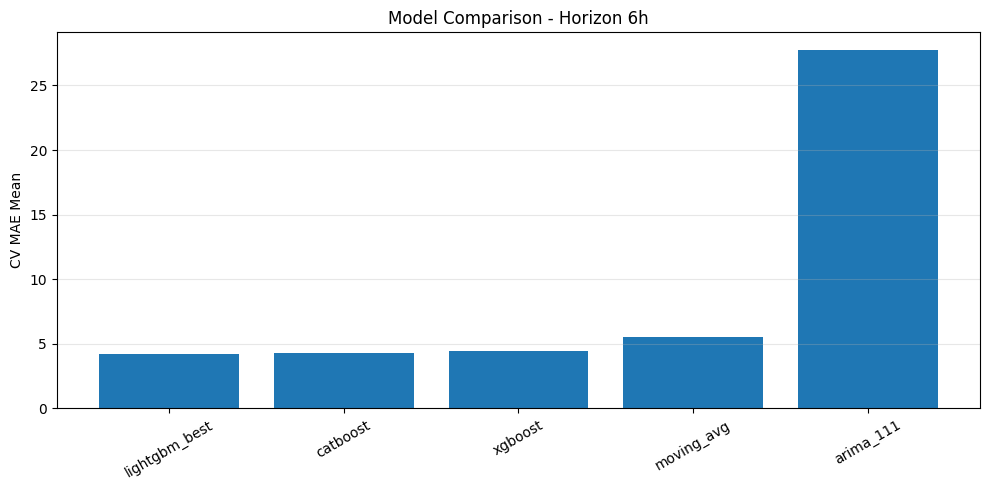

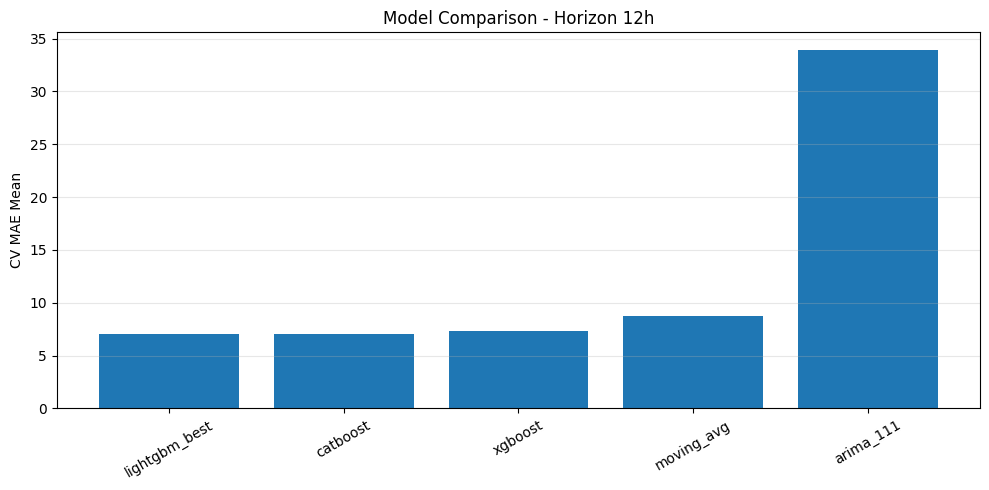

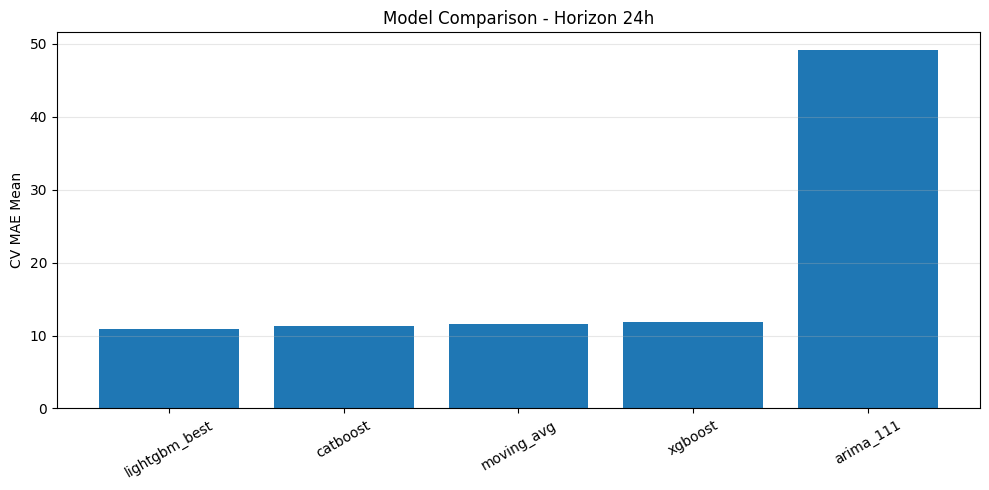

In [6]:
import matplotlib.pyplot as plt

for horizon in sorted(model_comparison_df["horizon"].unique()):
    sub = model_comparison_df[model_comparison_df["horizon"] == horizon].copy()
    sub = sub.sort_values("cv_mae_mean")

    plt.figure(figsize=(10, 5))
    plt.bar(sub["model"], sub["cv_mae_mean"])
    plt.xticks(rotation=30)
    plt.ylabel("CV MAE Mean")
    plt.title(f"Model Comparison - Horizon {horizon}h")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"model_comparison_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

## Menggabungkan File Prediksi Semua Model

Cell ini menggabungkan file prediksi per fold menjadi satu file prediksi final per horizon.

Sebelumnya, setiap model dan fold menghasilkan file prediksi terpisah dengan pola nama:

```text
predictions_h{horizon}_{model}_fold{fold_id}.csv
```

Karena ada 5 model dan 4 fold, maka untuk setiap horizon terdapat 20 file prediksi sementara.

Cell ini kemudian menggabungkan 20 file tersebut menjadi satu file final per horizon:

| Horizon | File Gabungan | Jumlah Baris |
|---:|---|---:|
| H6 | `outputs_model_comparison/merged_predictions/predictions_h6_all_models.csv` | 311.700 |
| H12 | `outputs_model_comparison/merged_predictions/predictions_h12_all_models.csv` | 311.600 |
| H24 | `outputs_model_comparison/merged_predictions/predictions_h24_all_models.csv` | 311.500 |

Setelah file gabungan berhasil disimpan, file prediksi per fold dihapus menggunakan `fp.unlink()`.

Artinya, folder `saved_predictions/` hanya digunakan sebagai tempat penyimpanan sementara. Output prediksi final yang dipertahankan adalah file di folder:

```text
outputs_model_comparison/merged_predictions/
```

Kolom utama pada file prediksi gabungan adalah:

| Kolom | Makna |
|---|---|
| `datetime` | Waktu input prediksi |
| `station_slug` | Identitas stasiun |
| `actual_target` | Nilai target PM2.5 aktual pada horizon terkait |
| `current_pm25` | Nilai PM2.5 pada waktu input |
| `prediction` | Nilai prediksi model |
| `fold_id` | Fold validasi |
| `horizon` | Horizon prediksi |
| `model` | Nama model |

File prediksi gabungan ini sangat berguna untuk analisis lanjutan, terutama untuk membuat grafik actual vs prediction per horizon, per fold, per stasiun, dan per model.

In [13]:
from pathlib import Path
import pandas as pd

# folder prediction hasil comparison
PRED_DIR = OUT_DIR / "saved_predictions"

# folder output final merged
MERGED_PRED_DIR = OUT_DIR / "merged_predictions"
MERGED_PRED_DIR.mkdir(exist_ok=True)

for horizon in [6, 12, 24]:
    pattern = f"predictions_h{horizon}_*_fold*.csv"
    files = sorted(PRED_DIR.glob(pattern))

    if not files:
        print(f"[SKIP] Tidak ada file untuk horizon h{horizon}")
        continue

    dfs = []
    for fp in files:
        df = pd.read_csv(fp)

        if "datetime" in df.columns:
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

        dfs.append(df)

    merged_df = pd.concat(dfs, ignore_index=True)

    # rapikan urutan kolom kalau tersedia
    preferred_cols = [
        "datetime", "station_slug", "actual_target", "current_pm25",
        "prediction", "fold_id", "horizon", "model"
    ]
    ordered_cols = [c for c in preferred_cols if c in merged_df.columns]
    remaining_cols = [c for c in merged_df.columns if c not in ordered_cols]
    merged_df = merged_df[ordered_cols + remaining_cols]

    # sort biar rapi
    sort_cols = [c for c in ["model", "fold_id", "datetime", "station_slug"] if c in merged_df.columns]
    if sort_cols:
        merged_df = merged_df.sort_values(sort_cols).reset_index(drop=True)

    out_path = MERGED_PRED_DIR / f"predictions_h{horizon}_all_models.csv"
    merged_df.to_csv(out_path, index=False)

    print(f"[SAVED] {out_path} | rows={len(merged_df):,}")

    # hapus file-file prediction per fold setelah berhasil merge
    for fp in files:
        fp.unlink()

    print(f"[DELETED] {len(files)} file fold prediction untuk h{horizon}")

print("\nSelesai. File prediction final yang tersisa:")
for fp in sorted(MERGED_PRED_DIR.glob("predictions_h*_all_models.csv")):
    print("-", fp)

[SAVED] outputs_model_comparison/merged_predictions/predictions_h6_all_models.csv | rows=311,700
[DELETED] 20 file fold prediction untuk h6
[SAVED] outputs_model_comparison/merged_predictions/predictions_h12_all_models.csv | rows=311,600
[DELETED] 20 file fold prediction untuk h12
[SAVED] outputs_model_comparison/merged_predictions/predictions_h24_all_models.csv | rows=311,500
[DELETED] 20 file fold prediction untuk h24

Selesai. File prediction final yang tersisa:
- outputs_model_comparison/merged_predictions/predictions_h12_all_models.csv
- outputs_model_comparison/merged_predictions/predictions_h24_all_models.csv
- outputs_model_comparison/merged_predictions/predictions_h6_all_models.csv


## Visualisasi Forecast H6 Fold 1: Actual vs Semua Model

Cell ini membuat visualisasi perbandingan nilai aktual dan prediksi model untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 6 jam |
| Fold | 1 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Visualisasi ini menampilkan:

| Garis | Makna |
|---|---|
| `GT / actual` | Nilai aktual target PM2.5 |
| `moving_avg` | Prediksi baseline moving average |
| `arima_111` | Prediksi ARIMA(1,1,1) |
| `lightgbm_best` | Prediksi LightGBM hasil tuning |
| `xgboost` | Prediksi XGBoost |
| `catboost` | Prediksi CatBoost |

Berbeda dari file prediksi gabungan, cell ini melatih ulang model tree pada fold yang dipilih, lalu membuat prediksi khusus untuk satu stasiun. Tujuannya adalah memberikan gambaran visual apakah prediksi model mengikuti pola aktual.

Pada H6 Fold 1, horizon masih pendek, sehingga model berbasis tree seharusnya lebih mampu mengikuti perubahan aktual dibanding baseline yang terlalu sederhana. Visualisasi ini membantu melihat model mana yang paling dekat dengan ground truth secara bentuk kurva, bukan hanya dari nilai MAE.

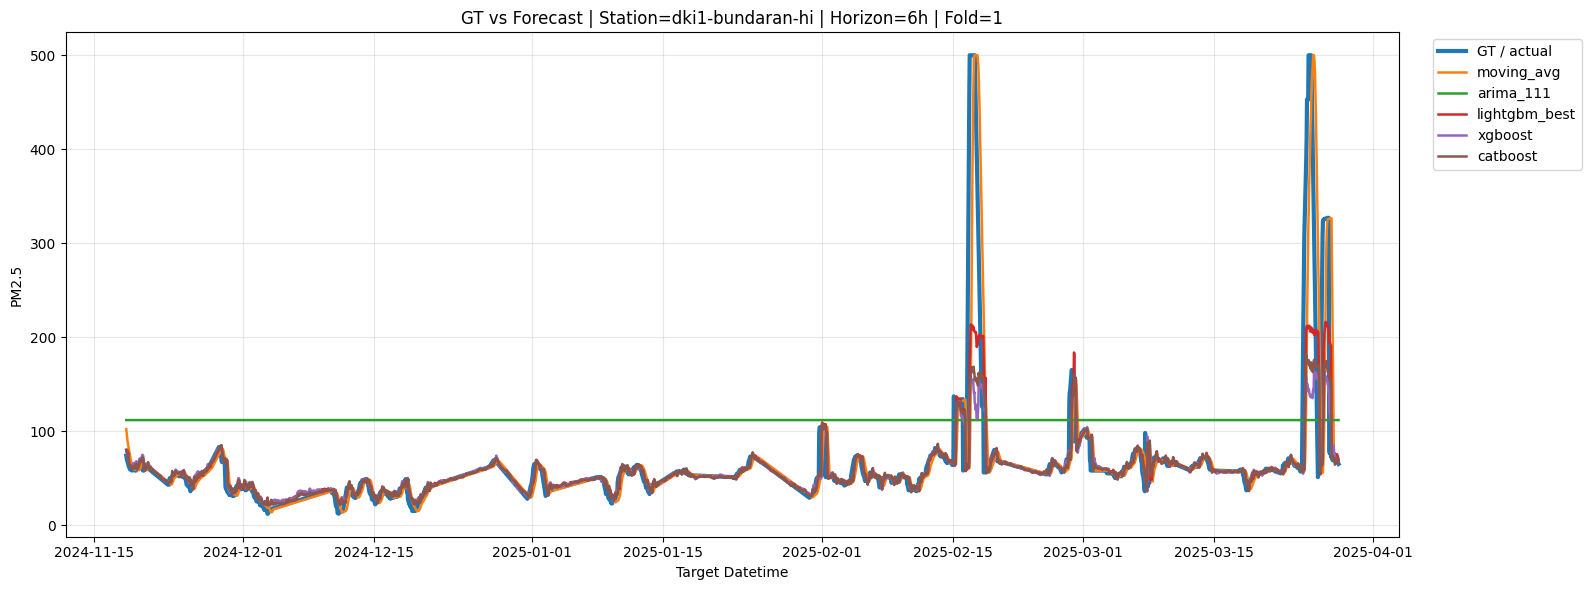

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2024-11-18 12:00:00,dki1-bundaran-hi,74.0,88.0,102.000000,79.708760,79.688599,80.274812,111.729424
1,2024-11-18 13:00:00,dki1-bundaran-hi,71.0,85.0,98.000000,77.662409,77.379814,78.102066,111.727487
2,2024-11-18 14:00:00,dki1-bundaran-hi,69.0,85.0,93.500000,78.358121,77.132538,78.130277,111.726011
3,2024-11-18 15:00:00,dki1-bundaran-hi,68.0,80.0,90.166667,79.460338,76.243340,78.495151,111.724886
4,2024-11-18 16:00:00,dki1-bundaran-hi,66.0,80.0,87.166667,74.651273,73.653694,73.829225,111.724029
5,2024-11-18 17:00:00,dki1-bundaran-hi,65.0,78.0,84.833333,76.846156,75.098495,76.379506,111.723375
6,2024-11-18 18:00:00,dki1-bundaran-hi,63.0,74.0,82.666667,70.122584,69.996269,69.814302,111.722878
7,2024-11-18 19:00:00,dki1-bundaran-hi,62.0,71.0,80.333333,67.669442,66.397903,65.396933,111.722498
8,2024-11-18 20:00:00,dki1-bundaran-hi,61.0,69.0,78.000000,65.814882,65.201149,63.850464,111.722209
9,2024-11-18 21:00:00,dki1-bundaran-hi,60.0,68.0,75.333333,65.083016,65.401634,63.504471,111.721989


In [7]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 6                    # 6 / 12 / 24
FOLD_ID = 1                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

## Visualisasi Forecast H6 Fold 4: Mengecek Konsistensi pada Periode Akhir

Cell ini membuat visualisasi actual vs prediction untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 6 jam |
| Fold | 4 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Fold 4 merepresentasikan periode validation paling akhir dalam skema walk-forward. Oleh karena itu, visualisasi ini penting untuk melihat apakah performa model tetap stabil pada periode data terbaru.

Hal yang dapat diamati dari grafik:

1. Apakah prediksi model mengikuti arah perubahan aktual.
2. Apakah model terlalu halus dan gagal menangkap lonjakan.
3. Apakah ada model yang cenderung overestimate atau underestimate.
4. Apakah LightGBM, XGBoost, dan CatBoost memiliki pola prediksi yang mirip.
5. Apakah baseline moving average masih cukup dekat dengan aktual.

Visualisasi fold 4 penting karena model final nantinya akan digunakan untuk memprediksi periode setelah data historis. Jika model bekerja baik pada fold paling akhir, maka model lebih menjanjikan untuk skenario operasional.

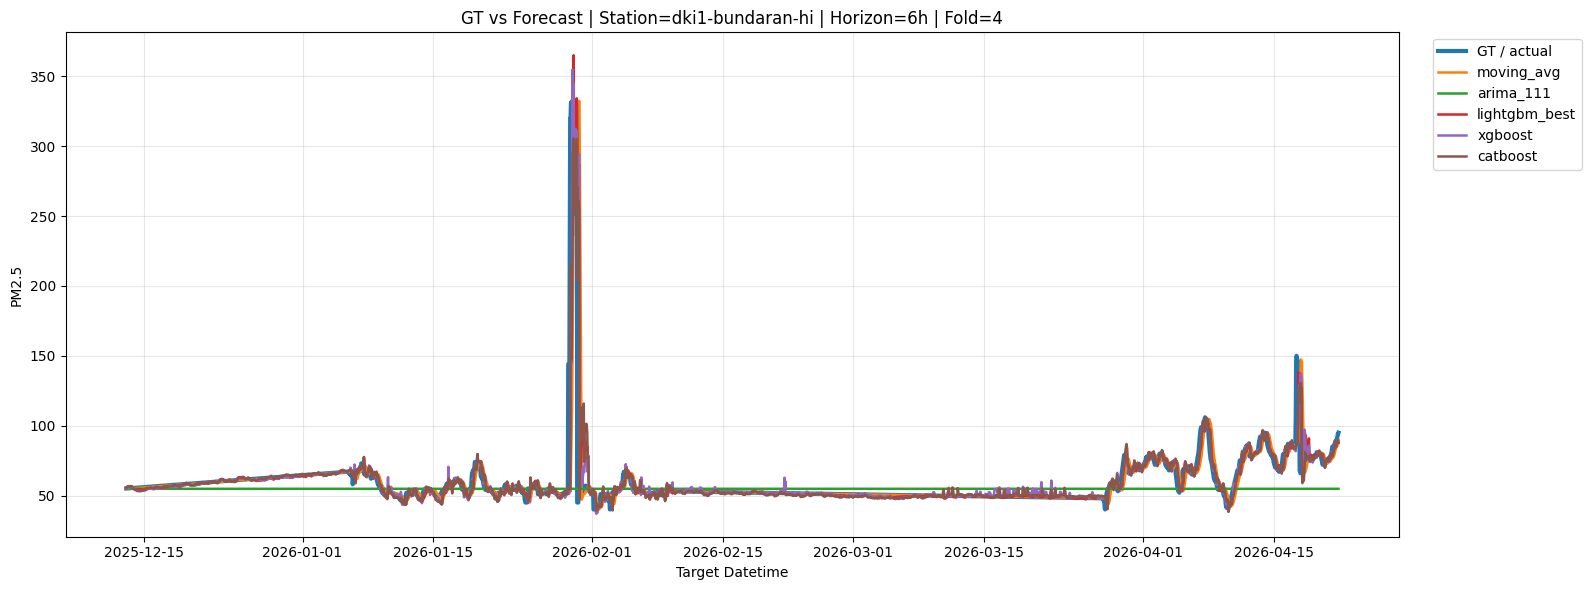

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2025-12-13 03:00:00,dki1-bundaran-hi,55.033283,54.906203,54.832073,55.250210,55.432255,55.643892,54.807683
1,2025-12-13 04:00:00,dki1-bundaran-hi,55.054463,54.927383,54.853253,55.049411,55.257690,55.477992,54.808392
2,2025-12-13 05:00:00,dki1-bundaran-hi,55.075643,54.948563,54.874433,56.098728,55.269283,56.102749,54.808972
3,2025-12-13 06:00:00,dki1-bundaran-hi,55.096823,54.969743,54.895613,56.393296,55.160961,56.402231,54.809445
4,2025-12-13 07:00:00,dki1-bundaran-hi,55.118003,54.990923,54.916793,56.364629,55.205887,56.373173,54.809832
5,2025-12-13 08:00:00,dki1-bundaran-hi,55.139183,55.012103,54.937973,56.574636,56.118217,56.801824,54.810148
6,2025-12-13 09:00:00,dki1-bundaran-hi,55.160363,55.033283,54.959153,56.470027,55.953564,56.612076,54.810406
7,2025-12-13 10:00:00,dki1-bundaran-hi,55.181543,55.054463,54.980333,56.561296,55.780655,56.459572,54.810617
8,2025-12-13 11:00:00,dki1-bundaran-hi,55.202723,55.075643,55.001513,56.618609,55.868713,56.570330,54.810789
9,2025-12-13 12:00:00,dki1-bundaran-hi,55.223903,55.096823,55.022693,56.567772,55.850971,56.449911,54.810930


In [8]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 6                    # 6 / 12 / 24
FOLD_ID = 4                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

## Visualisasi Forecast H12 Fold 1: Prediksi Setengah Hari ke Depan

Cell ini membuat visualisasi actual vs prediction untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 12 jam |
| Fold | 1 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Pada horizon 12 jam, model harus memprediksi PM2.5 setengah hari ke depan. Tantangannya lebih besar dibanding H6 karena informasi PM2.5 terbaru tidak lagi sekuat pada prediksi jangka pendek.

Visualisasi ini membantu melihat:

| Aspek | Tujuan |
|---|---|
| Kedekatan kurva prediksi dengan aktual | Menilai akurasi visual |
| Respons terhadap perubahan PM2.5 | Melihat apakah model mengikuti naik-turun aktual |
| Perbedaan antar model | Membandingkan pola prediksi model tree dan baseline |
| Stabilitas prediksi | Melihat apakah prediksi terlalu berfluktuasi atau terlalu datar |

Pada horizon ini, model berbasis tree diharapkan masih mampu menangkap pola aktual melalui kombinasi fitur lag, rolling, waktu, musim, dan cuaca.

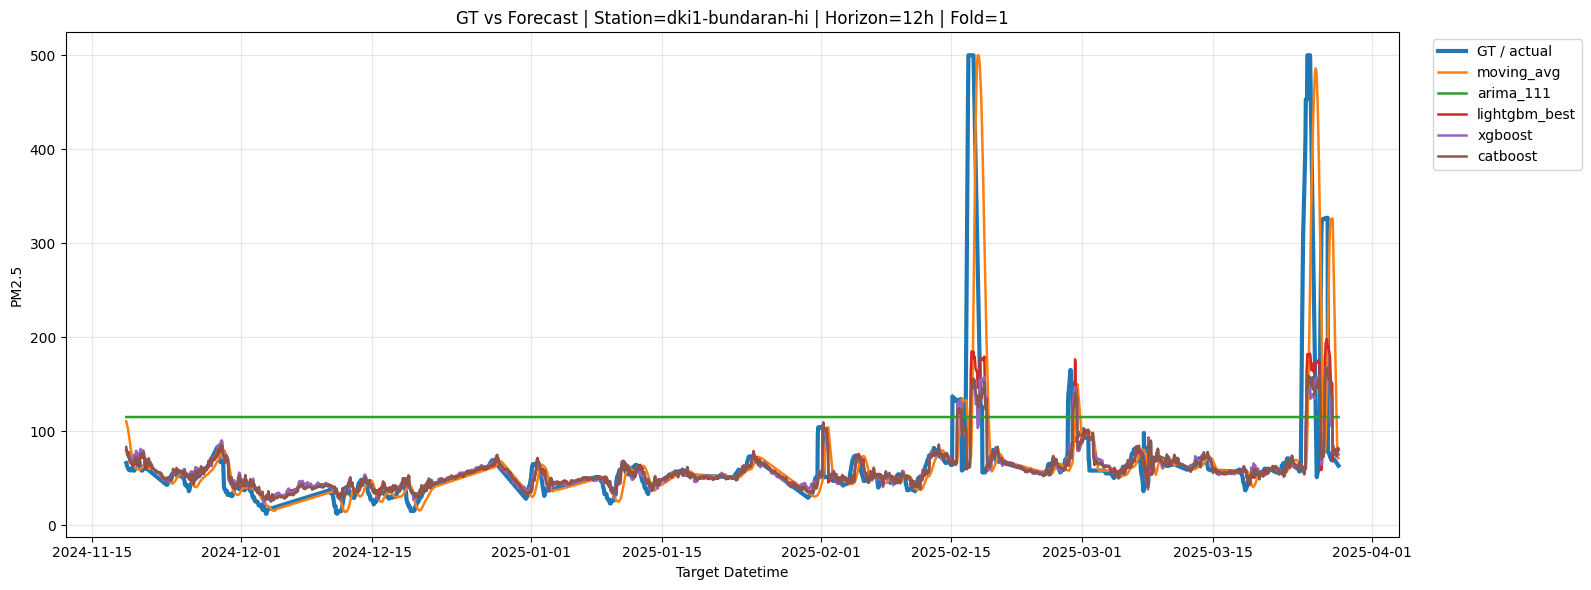

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2024-11-18 16:00:00,dki1-bundaran-hi,66.0,94.0,110.416667,80.617817,79.392532,83.059204,114.978159
1,2024-11-18 17:00:00,dki1-bundaran-hi,65.0,91.0,108.750000,80.240144,78.666931,79.035113,114.977886
2,2024-11-18 18:00:00,dki1-bundaran-hi,63.0,88.0,107.000000,77.175591,75.870590,76.879037,114.977678
3,2024-11-18 19:00:00,dki1-bundaran-hi,62.0,85.0,105.083333,75.566724,75.854683,74.018765,114.977519
4,2024-11-18 20:00:00,dki1-bundaran-hi,61.0,85.0,102.833333,77.261325,76.320282,74.095208,114.977398
5,2024-11-18 21:00:00,dki1-bundaran-hi,60.0,80.0,100.583333,77.903386,77.395775,77.482558,114.977306
6,2024-11-18 22:00:00,dki1-bundaran-hi,59.0,80.0,97.833333,74.779883,71.598030,71.795027,114.977236
7,2024-11-18 23:00:00,dki1-bundaran-hi,59.0,78.0,95.166667,77.292111,74.365997,75.583680,114.977182
8,2024-11-19 00:00:00,dki1-bundaran-hi,59.0,74.0,92.333333,71.251021,70.950043,70.290716,114.977141
9,2024-11-19 01:00:00,dki1-bundaran-hi,59.0,71.0,89.166667,68.286800,69.709763,66.961814,114.977110


In [9]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 12                    # 6 / 12 / 24
FOLD_ID = 1                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

## Visualisasi Forecast H12 Fold 4: Validasi pada Periode Terbaru

Cell ini membuat visualisasi actual vs prediction untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 12 jam |
| Fold | 4 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Fold 4 digunakan untuk mengecek performa model pada periode validation paling akhir. Untuk horizon 12 jam, visualisasi ini penting karena model harus menangkap pola setengah harian pada periode terbaru.

Hal yang perlu diperhatikan:

1. Apakah LightGBM masih mengikuti pola aktual dengan baik.
2. Apakah CatBoost dan XGBoost memberikan prediksi yang sebanding.
3. Apakah moving average terlalu lambat merespons perubahan aktual.
4. Apakah ARIMA cenderung terlalu datar atau bias.
5. Apakah model mengalami underprediction atau overprediction pada periode tertentu.

Jika pola prediksi pada fold 4 tetap stabil, maka model memiliki indikasi generalisasi yang cukup baik untuk horizon menengah.

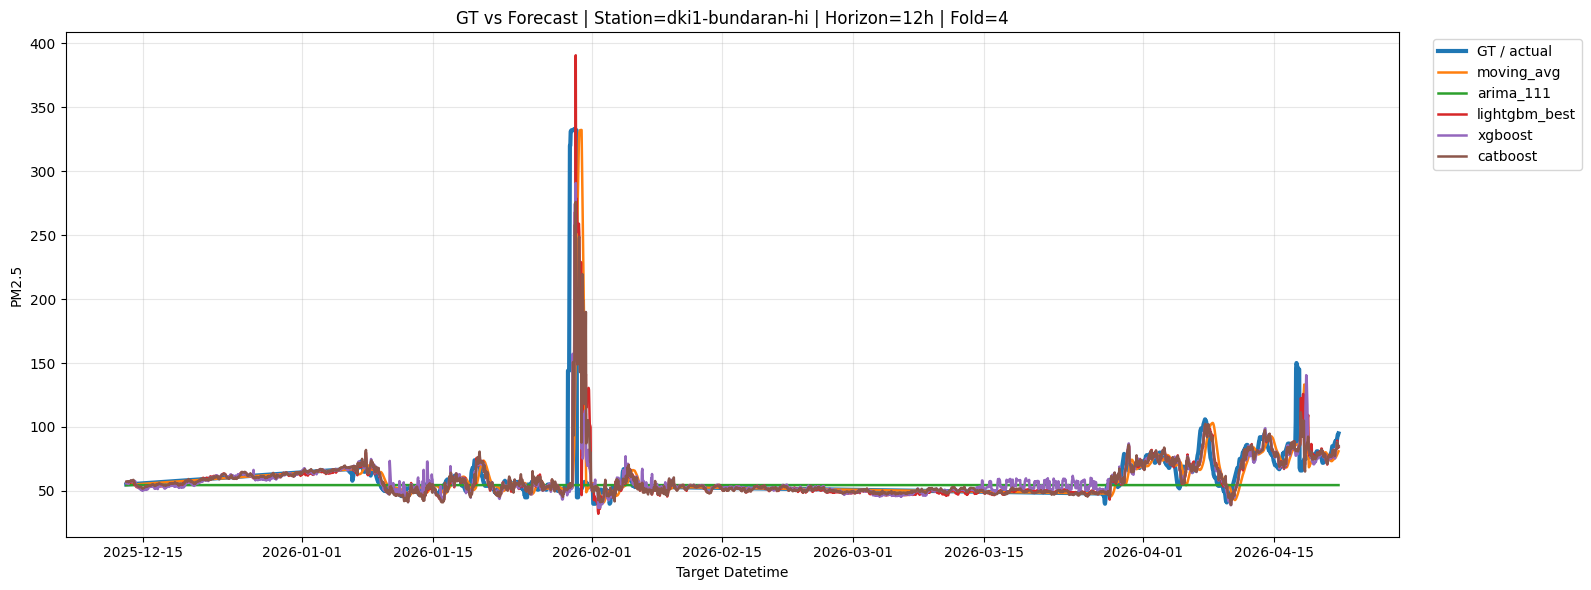

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2025-12-13 04:00:00,dki1-bundaran-hi,55.054463,54.800303,54.662632,56.305660,55.996433,57.253039,54.578236
1,2025-12-13 05:00:00,dki1-bundaran-hi,55.075643,54.821483,54.683812,56.195926,55.942509,57.117116,54.578298
2,2025-12-13 06:00:00,dki1-bundaran-hi,55.096823,54.842663,54.704992,56.285267,55.889801,57.186974,54.578350
3,2025-12-13 07:00:00,dki1-bundaran-hi,55.118003,54.863843,54.726172,56.510368,55.910637,57.555126,54.578392
4,2025-12-13 08:00:00,dki1-bundaran-hi,55.139183,54.885023,54.747352,56.160705,55.657887,57.365159,54.578426
5,2025-12-13 09:00:00,dki1-bundaran-hi,55.160363,54.906203,54.768533,55.998133,55.629990,57.469755,54.578454
6,2025-12-13 10:00:00,dki1-bundaran-hi,55.181543,54.927383,54.789713,55.618870,55.481110,56.819256,54.578477
7,2025-12-13 11:00:00,dki1-bundaran-hi,55.202723,54.948563,54.810893,56.351292,57.382298,57.225309,54.578495
8,2025-12-13 12:00:00,dki1-bundaran-hi,55.223903,54.969743,54.832073,56.477687,57.177254,57.415445,54.578511
9,2025-12-13 13:00:00,dki1-bundaran-hi,55.245083,54.990923,54.853253,56.741242,57.280327,57.261334,54.578523


In [10]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 12                    # 6 / 12 / 24
FOLD_ID = 4                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

## Visualisasi Forecast H24 Fold 1: Prediksi Satu Hari ke Depan

Cell ini membuat visualisasi actual vs prediction untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 24 jam |
| Fold | 1 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Horizon 24 jam adalah skenario prediksi paling sulit dalam notebook ini karena model harus memperkirakan PM2.5 satu hari ke depan.

Pada horizon ini, fitur jangka pendek saja tidak cukup. Model perlu memanfaatkan:

1. Pola harian.
2. Fitur lag panjang.
3. Rolling statistics.
4. Fitur cuaca.
5. Fitur musim.
6. Identitas stasiun.

Visualisasi H24 Fold 1 membantu melihat apakah model mampu menangkap pola umum PM2.5 pada horizon panjang. Jika prediksi terlihat terlalu datar, berarti model belum cukup responsif terhadap perubahan aktual. Jika prediksi terlalu fluktuatif, berarti model mungkin terlalu sensitif terhadap noise.

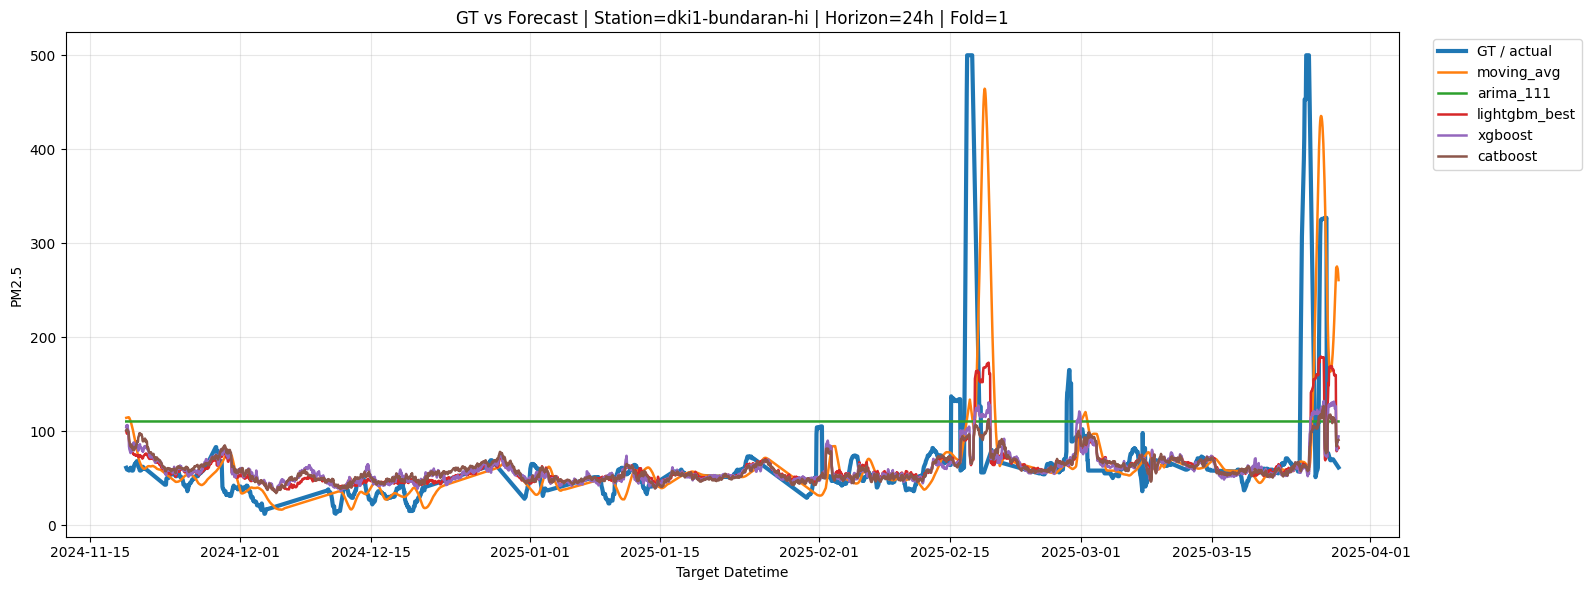

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2024-11-18 20:00:00,dki1-bundaran-hi,61.0,112.0,114.125000,100.081373,104.714500,100.709653,110.257578
1,2024-11-18 21:00:00,dki1-bundaran-hi,60.0,113.0,114.250000,98.080888,106.284805,101.629571,110.257578
2,2024-11-18 22:00:00,dki1-bundaran-hi,59.0,112.0,114.416667,97.135741,101.074066,100.862249,110.257578
3,2024-11-18 23:00:00,dki1-bundaran-hi,59.0,112.0,114.541667,98.749059,106.449959,101.435558,110.257578
4,2024-11-19 00:00:00,dki1-bundaran-hi,59.0,112.0,114.625000,99.615989,102.688721,99.094680,110.257578
5,2024-11-19 01:00:00,dki1-bundaran-hi,59.0,112.0,114.708333,100.070198,100.910194,99.498407,110.257578
6,2024-11-19 02:00:00,dki1-bundaran-hi,59.0,105.0,114.791667,97.604993,97.735031,98.815437,110.257578
7,2024-11-19 03:00:00,dki1-bundaran-hi,58.0,98.0,114.583333,90.231015,83.828804,92.157808,110.257578
8,2024-11-19 04:00:00,dki1-bundaran-hi,59.0,94.0,113.916667,86.999251,80.857773,88.876408,110.257578
9,2024-11-19 05:00:00,dki1-bundaran-hi,60.0,91.0,113.000000,85.976200,79.377426,86.975811,110.257578


In [11]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 24                    # 6 / 12 / 24
FOLD_ID = 1                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

## Visualisasi Forecast H24 Fold 4: Uji Stabilitas Horizon Terpanjang

Cell ini membuat visualisasi actual vs prediction untuk:

| Komponen | Nilai |
|---|---|
| Horizon | 24 jam |
| Fold | 4 |
| Stasiun | `dki1-bundaran-hi` |
| ARIMA order | `(1, 1, 1)` |

Fold 4 pada H24 menjadi salah satu visualisasi paling penting karena menguji model pada periode terbaru dengan horizon prediksi paling panjang.

Pada grafik ini, kita dapat mengevaluasi apakah model masih mampu mengikuti pola aktual ketika target berada 24 jam ke depan. Biasanya, semakin panjang horizon, prediksi akan:

1. Menjadi lebih halus.
2. Lebih sulit menangkap lonjakan tiba-tiba.
3. Lebih bergantung pada pola harian dan musiman.
4. Memiliki error lebih besar dibanding H6 dan H12.

Berdasarkan hasil metrik sebelumnya, H24 memang memiliki CV MAE paling besar. Oleh karena itu, visualisasi ini membantu menjelaskan secara visual mengapa prediksi 24 jam lebih sulit dibanding horizon yang lebih pendek.

Cell ini tidak menyimpan file gambar secara otomatis karena hanya menggunakan `plt.show()`. Jika grafik ingin disimpan, perlu ditambahkan `plt.savefig()` sebelum `plt.show()`.

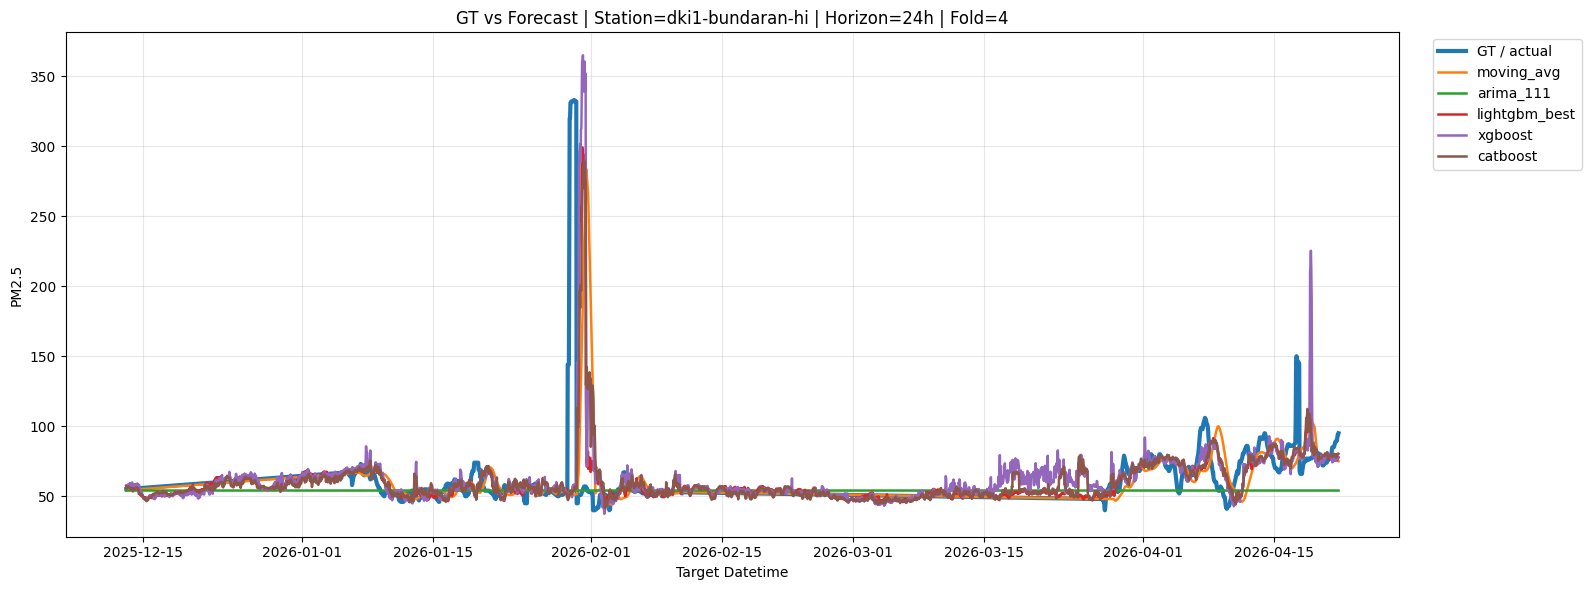

,target_datetime,station_slug,actual,pm25,moving_avg,lightgbm_best,xgboost,catboost,arima_111
0,2025-12-13 05:00:00,dki1-bundaran-hi,55.075643,54.567322,54.302572,57.640959,57.308113,57.020376,54.091435
1,2025-12-13 06:00:00,dki1-bundaran-hi,55.096823,54.588502,54.323752,56.390900,56.583786,55.287692,54.091436
2,2025-12-13 07:00:00,dki1-bundaran-hi,55.118003,54.609682,54.344932,57.115347,57.084507,56.191754,54.091436
3,2025-12-13 08:00:00,dki1-bundaran-hi,55.139183,54.630862,54.366112,58.018955,57.888126,56.475612,54.091436
4,2025-12-13 09:00:00,dki1-bundaran-hi,55.160363,54.652042,54.387292,57.871208,57.325478,56.785956,54.091437
5,2025-12-13 10:00:00,dki1-bundaran-hi,55.181543,54.673222,54.408472,58.258131,57.962906,56.887687,54.091437
6,2025-12-13 11:00:00,dki1-bundaran-hi,55.202723,54.694402,54.429652,58.343720,57.921097,56.907072,54.091437
7,2025-12-13 12:00:00,dki1-bundaran-hi,55.223903,54.715582,54.450832,57.994523,57.616322,56.492804,54.091437
8,2025-12-13 13:00:00,dki1-bundaran-hi,55.245083,54.736762,54.472012,57.949693,57.618946,56.255167,54.091437
9,2025-12-13 14:00:00,dki1-bundaran-hi,55.266263,54.757943,54.493192,58.261548,59.427937,56.481050,54.091437


In [12]:
# =========================
# ONE-CELL VISUALIZATION: GT vs forecasts
# Requires helper functions already defined earlier:
# - load_dataset
# - make_walk_forward_folds
# - prepare_xy_onehot
# - choose_moving_average_col
# - load_best_lgb_params
# and imports/models:
# - LGBMRegressor, XGBRegressor, CatBoostRegressor, ARIMA
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# ---------- pilih yang mau divisualisasikan ----------
HORIZON = 24                    # 6 / 12 / 24
FOLD_ID = 4                    # 1..4
STATION_SLUG = "dki1-bundaran-hi"
ARIMA_ORDER = (1, 1, 1)
# ----------------------------------------------------

# load data + fold
df = load_dataset(DATASET_PATHS[HORIZON]).copy()
df["horizon_used"] = HORIZON
target_col = f"target_pm25_t_plus_{HORIZON}"

folds = make_walk_forward_folds(df, horizon=HORIZON, n_folds=N_FOLDS, valid_ratio_each=0.10)
fold = [f for f in folds if f["fold_id"] == FOLD_ID][0]

train_idx = fold["train_idx"]
valid_idx = fold["valid_idx"]

train_df = df.iloc[train_idx].copy()
valid_df = df.iloc[valid_idx].copy()
valid_station = valid_df[valid_df["station_slug"] == STATION_SLUG].copy()

if valid_station.empty:
    raise ValueError(f"Tidak ada data valid untuk {STATION_SLUG}, horizon={HORIZON}, fold={FOLD_ID}")

# target datetime = waktu prediksi yang dibandingkan dengan GT
plot_df = valid_station[["datetime", "station_slug", target_col, "pm25"]].copy()
plot_df["target_datetime"] = plot_df["datetime"] + pd.Timedelta(hours=HORIZON)
plot_df = plot_df.rename(columns={target_col: "actual"})
plot_df = plot_df[["target_datetime", "station_slug", "actual", "pm25"]].sort_values("target_datetime").reset_index(drop=True)

# ---------- baseline: moving average ----------
ma_col = choose_moving_average_col(df, HORIZON)
if ma_col is None:
    raise ValueError("Kolom moving average tidak ditemukan.")
plot_df["moving_avg"] = valid_station[ma_col].values

# ---------- tree models on full fold ----------
X_all, y_all = prepare_xy_onehot(df, target_col)
X_train = X_all.iloc[train_idx].copy()
y_train = y_all.iloc[train_idx].copy()
X_valid = X_all.iloc[valid_idx].copy()

valid_meta = valid_df[["datetime", "station_slug"]].copy()
valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=HORIZON)

# LightGBM best
lgb_params = load_best_lgb_params(HORIZON)
lgb_model = LGBMRegressor(random_state=SEED, verbose=-1, **lgb_params)
lgb_model.fit(X_train, y_train)
pred_lgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "lightgbm_best": lgb_model.predict(X_valid)
})
pred_lgb = pred_lgb[pred_lgb["station_slug"] == STATION_SLUG]

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "xgboost": xgb_model.predict(X_valid)
})
pred_xgb = pred_xgb[pred_xgb["station_slug"] == STATION_SLUG]

# CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_train, y_train)
pred_cat = pd.DataFrame({
    "target_datetime": valid_meta["target_datetime"].values,
    "station_slug": valid_meta["station_slug"].values,
    "catboost": cat_model.predict(X_valid)
})
pred_cat = pred_cat[pred_cat["station_slug"] == STATION_SLUG]

# ---------- ARIMA per station ----------
tr = train_df[train_df["station_slug"] == STATION_SLUG].copy().sort_values("datetime").drop_duplicates("datetime")
va = valid_station.copy().sort_values("datetime").drop_duplicates("datetime")
va["target_datetime"] = va["datetime"] + pd.Timedelta(hours=HORIZON)

s = tr.set_index("datetime")["pm25"].asfreq("h").ffill().bfill()

if len(s) < 10:
    va["arima_111"] = va["pm25"].values
else:
    try:
        arima_model = ARIMA(s, order=ARIMA_ORDER).fit()
        last_train_time = s.index.max()
        max_target_time = va["target_datetime"].max()
        n_steps = max(1, int((max_target_time - last_train_time) / pd.Timedelta(hours=1)))
        fc = arima_model.forecast(steps=n_steps)
        fc_index = pd.date_range(start=last_train_time + pd.Timedelta(hours=1), periods=n_steps, freq="h")
        fc_series = pd.Series(fc, index=fc_index)
        va["arima_111"] = va["target_datetime"].map(fc_series).fillna(va["pm25"])
    except Exception:
        va["arima_111"] = va["pm25"].values

pred_arima = va[["target_datetime", "arima_111"]].copy()

# ---------- merge semua prediksi ----------
plot_df = plot_df.merge(pred_lgb[["target_datetime", "lightgbm_best"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_xgb[["target_datetime", "xgboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_cat[["target_datetime", "catboost"]], on="target_datetime", how="left")
plot_df = plot_df.merge(pred_arima, on="target_datetime", how="left")
plot_df = plot_df.sort_values("target_datetime").reset_index(drop=True)

# ---------- plot GT vs all models ----------
plt.figure(figsize=(16, 6))
plt.plot(plot_df["target_datetime"], plot_df["actual"], label="GT / actual", linewidth=3)

for col in ["moving_avg", "arima_111", "lightgbm_best", "xgboost", "catboost"]:
    if col in plot_df.columns:
        plt.plot(plot_df["target_datetime"], plot_df[col], label=col, linewidth=1.8)

plt.xlabel("Target Datetime")
plt.ylabel("PM2.5")
plt.title(f"GT vs Forecast | Station={STATION_SLUG} | Horizon={HORIZON}h | Fold={FOLD_ID}")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# optional: lihat tabelnya
display(plot_df.head(20))

# Struktur Folder dan File Output Notebook

Notebook ini menghasilkan satu folder output utama:

```text
outputs_model_comparison/
```

Input utama notebook adalah:

```text
dataset_h6.csv
dataset_h12.csv
dataset_h24.csv
```

Notebook juga membaca best params LightGBM dari folder hasil optimasi sebelumnya:

```text
outputs_phase2/
```

Struktur output notebook dapat diringkas sebagai berikut:

```text
project/
│
├── dataset_h6.csv
├── dataset_h12.csv
├── dataset_h24.csv
│
├── outputs_phase2/
│   ├── best_params_h6.json
│   ├── best_params_h12.json
│   └── best_params_h24.json
│
├── model_comparison.csv
│
└── outputs_model_comparison/
    ├── model_comparison_by_fold.csv
    ├── model_comparison_h6.png
    ├── model_comparison_h12.png
    ├── model_comparison_h24.png
    │
    ├── saved_models/
    │   ├── model_h6_xgboost_fold1.pkl
    │   ├── model_h6_xgboost_fold2.pkl
    │   ├── model_h6_xgboost_fold3.pkl
    │   ├── model_h6_xgboost_fold4.pkl
    │   ├── model_h6_catboost_fold1.pkl
    │   ├── model_h6_catboost_fold2.pkl
    │   ├── ...
    │   ├── model_h24_xgboost_fold4.pkl
    │   └── model_h24_catboost_fold4.pkl
    │
    ├── saved_predictions/
    │   └── kosong setelah file per-fold digabung dan dihapus
    │
    └── merged_predictions/
        ├── predictions_h6_all_models.csv
        ├── predictions_h12_all_models.csv
        └── predictions_h24_all_models.csv
```

### Penjelasan File Output

| File atau Folder | Fungsi |
|---|---|
| `model_comparison.csv` | Ringkasan rata-rata performa model per horizon |
| `outputs_model_comparison/model_comparison_by_fold.csv` | Detail performa model per fold |
| `outputs_model_comparison/model_comparison_h6.png` | Grafik perbandingan MAE model untuk H6 |
| `outputs_model_comparison/model_comparison_h12.png` | Grafik perbandingan MAE model untuk H12 |
| `outputs_model_comparison/model_comparison_h24.png` | Grafik perbandingan MAE model untuk H24 |
| `outputs_model_comparison/saved_models/` | Folder penyimpanan model XGBoost dan CatBoost per fold |
| `outputs_model_comparison/saved_predictions/` | Folder sementara untuk prediksi per fold |
| `outputs_model_comparison/merged_predictions/` | Folder prediksi final gabungan semua model |

### File Prediksi Gabungan

| File | Isi |
|---|---|
| `predictions_h6_all_models.csv` | Prediksi semua model untuk horizon 6 jam |
| `predictions_h12_all_models.csv` | Prediksi semua model untuk horizon 12 jam |
| `predictions_h24_all_models.csv` | Prediksi semua model untuk horizon 24 jam |

### Ringkasan Model Terbaik

| Horizon | Model Terbaik | CV MAE Mean |
|---:|---|---:|
| H6 | `lightgbm_best` | 4.2338 |
| H12 | `lightgbm_best` | 7.0044 |
| H24 | `lightgbm_best` | 10.8273 |

Secara keseluruhan, notebook ini menunjukkan bahwa `lightgbm_best` menjadi model terbaik untuk semua horizon prediksi. CatBoost menjadi pesaing terdekat, terutama pada H6 dan H12, sedangkan ARIMA(1,1,1) memiliki performa paling lemah.

Output terpenting dari notebook ini adalah:

```text
model_comparison.csv
outputs_model_comparison/model_comparison_by_fold.csv
outputs_model_comparison/merged_predictions/predictions_h6_all_models.csv
outputs_model_comparison/merged_predictions/predictions_h12_all_models.csv
outputs_model_comparison/merged_predictions/predictions_h24_all_models.csv
```

File-file tersebut dapat digunakan untuk analisis lanjutan, visualisasi forecast, pemilihan model final, dan pelaporan hasil eksperimen.